# EDA — Tech Challenge Fase 1: NPS Preditivo

## Contexto
A empresa coleta o NPS apenas após o encerramento da jornada de compra, o que
limita a capacidade de antecipar problemas e agir de forma proativa. Mesmo com
indicadores operacionais aparentemente semelhantes, clientes divergem entre
promotores e detratores — o que sugere que fatores específicos da operação
(logística, atendimento, pedido) explicam essa diferença.

## Objetivo desta análise
Explorar a base de dados operacional (pedidos, entregas e atendimento) com foco
em negócio, para responder:

- Quais fatores parecem mais críticos para a satisfação do cliente?
- O que mais gera detratores?
- Existe algum "ponto de ruptura" na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

## Variável-alvo
`nps_score` — nota de satisfação (0 a 10) coletada após a experiência de compra.

## Estrutura do notebook
0. Data quality
1. Exploração variável por variável
2. Fatores mais críticos para a satisfação
3. O que gera detratores
4. Ponto de ruptura na experiência
5. Perfil de cliente por faixa de NPS

### Data Quality

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('desafio_nps_fase_1.csv')
df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7


In [ ]:
df.shape

(2500, 19)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [ ]:
df.isna().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include='all')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1250.50000,43.396000,NaN,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,NaN,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,NaN,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,NaN,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,NaN,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,NaN,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000


In [ ]:
df.customer_id.nunique()

2500

In [ ]:
df.order_id.nunique()

2500

In [ ]:
df.customer_region.value_counts()

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

In [ ]:
range_nps = df['nps_score'].between(0, 10).all()
range_nps

np.True_

In [ ]:
range_csat = df['csat_internal_score'].between(0, 10).all()
range_csat

np.True_

Ambas as variáveis-alvo (`nps_score` e `csat_internal_score`) estão dentro do range esperado (0-10), sem necessidade de tratamento.

In [ ]:
# Desconto maior que o valor do pedido

inconsistencia_desconto = df['discount_value'] > df['order_value']
df[inconsistencia_desconto]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
57,58,54,Sul,101,50058,86.15,2,112.42,11,10,3,36.23,3,1,0,8.4,1,2,5.5
116,117,28,Centro-Oeste,38,50117,60.96,2,95.06,4,9,0,30.19,2,0,7,7.8,0,1,5.2
182,183,41,Sudeste,104,50183,24.00,6,85.49,10,5,2,29.58,3,0,9,4.0,0,4,1.4
270,271,59,Nordeste,80,50271,79.93,2,129.11,6,2,4,27.59,1,1,1,1.1,0,3,4.8
273,274,58,Norte,11,50274,47.07,1,50.24,3,7,2,32.58,1,1,11,4.4,0,4,0.0
297,298,64,Centro-Oeste,7,50298,59.81,4,64.05,3,9,1,34.68,2,3,5,0.6,0,5,3.7
318,319,35,Norte,107,50319,27.57,1,44.05,11,14,1,26.09,2,0,3,2.8,0,2,6.6
349,350,39,Sul,97,50350,22.06,5,41.75,4,8,3,31.92,1,1,7,3.8,0,5,1.3
359,360,56,Sudeste,52,50360,28.27,3,30.59,4,13,3,37.13,3,0,10,1.9,0,3,0.7


In [ ]:
inconsistencia_desconto.sum() / df.shape[0] * 100

np.float64(1.4000000000000001)

1,4% da base tem desconto (`discount_value`) maior que o valor total do pedido (`order_value`), o que é logicamente inconsistente.

In [ ]:
# Atraso maior que o tempo de entrega

inconsistencia_atraso = df['delivery_delay_days'] > df['delivery_time_days']
df[inconsistencia_atraso]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
18,19,43,Sul,86,50019,383.98,3,33.61,11,3,4,25.24,2,2,3,3.4,0,4,2.0
41,42,48,Centro-Oeste,15,50042,117.97,2,28.35,5,2,3,28.02,2,2,11,1.8,0,6,0.0
46,47,58,Sudeste,33,50047,461.42,3,27.91,3,4,6,45.25,2,1,0,2.3,0,5,2.5
58,59,33,Sul,108,50059,385.42,5,13.86,2,2,3,52.49,2,3,2,3.1,0,5,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2243,2244,31,Centro-Oeste,97,52244,556.18,2,25.01,9,2,5,53.27,2,2,6,0.8,0,6,0.0
2264,2265,56,Centro-Oeste,69,52265,341.99,3,6.15,5,3,5,41.34,2,1,4,4.5,0,4,0.2
2341,2342,47,Norte,50,52342,457.36,1,34.52,1,2,3,33.89,1,1,2,2.5,0,3,4.8
2389,2390,34,Norte,89,52390,155.97,5,11.39,5,2,3,33.04,1,3,6,0.4,0,6,0.0


In [ ]:
inconsistencia_atraso.sum() / df.shape[0] * 100

np.float64(4.84)

4,84% da base tem atraso (`delivery_delay_days`) maior que o próprio tempo total de entrega (`delivery_time_days`), o que é logicamente inconsistente, o atraso deveria estar contido no tempo total, não excedê-lo.

In [ ]:
# Inconsistência de contato

inconsistencia_contato = (df['complaints_count'] > 0) & (df['customer_service_contacts'] == 0)
df[inconsistencia_contato]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2
10,11,50,Centro-Oeste,28,50011,616.17,2,23.00,8,4,2,52.94,3,0,7,5.3,0,6,2.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463,2464,69,Centro-Oeste,95,52464,385.14,1,12.27,6,10,3,33.19,2,0,6,4.6,0,4,2.8
2470,2471,48,Nordeste,40,52471,48.55,6,2.39,7,11,4,29.46,3,0,6,2.6,0,2,2.1
2488,2489,30,Nordeste,16,52489,374.87,3,32.30,2,5,4,57.00,3,0,1,3.6,0,4,4.4
2489,2490,50,Nordeste,118,52490,151.89,5,3.69,3,7,1,41.43,1,0,9,8.7,1,1,3.1


In [ ]:
inconsistencia_contato.sum() / df.shape[0] * 100

np.float64(21.240000000000002)

21,24% da base mostra reclamação registrada (`complaints_count > 0`) sem nenhum contato de atendimento (`customer_service_contacts == 0`). 

Volume alto demais pra ser outlier pontual, será tratado como limitação da base (provável geração sintética sem dependência lógica entre essas colunas), não como erro a corrigir. 

Decisão: manter as linhas, sem assumir causalidade entre reclamação e contato nas análises seguintes.

## 1. Exploração variável por variável

Para cada variável operacional, analisamos distribuição individual e relação
com a satisfação (`nps_score`), antes de comparar a importância relativa entre
elas nos capítulos seguintes.

Seguiremos com a ordem de análise:

- Logística
- Atendimento
- Pedido
- Perfil

### Criação das funções de explorações

count    2500.000000
mean        2.187200
std         1.454442
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: delivery_delay_days, dtype: float64


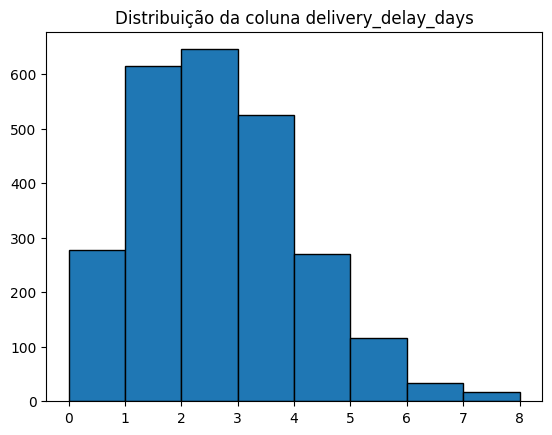

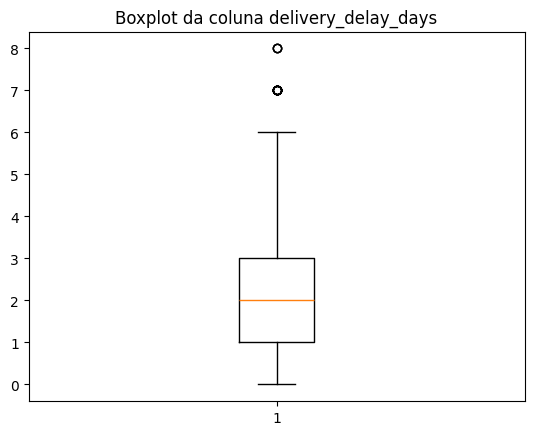

In [ ]:
## Função de distribuição univariada

def plot_distribution(df, coluna):
    coluna = df[coluna]

    if pd.api.types.is_numeric_dtype(coluna):
        print(coluna.describe())
        plt.hist(coluna, bins=range(int(coluna.min()), int(coluna.max()) + 1), edgecolor='black')
        plt.title(f'Distribuição da coluna {coluna.name}')
        plt.show()
        plt.boxplot(coluna)
        plt.title(f'Boxplot da coluna {coluna.name}')
        plt.show()
    else:
        print(coluna.value_counts())
        coluna.value_counts().plot(kind='bar')
        plt.title(f'Distribuição da coluna {coluna.name}')
        plt.show()

plot_distribution(df, 'delivery_delay_days')

Função de distribuição univariada ->

- **`plot_distribution(df, coluna)`**: mostra a distribuição individual da variável: estatística resumo + histograma (numéricas) ou contagem por categoria + gráfico de barras (categóricas), além de um boxplot para identificar outliers (Mediana e percentils) nas variáveis numéricas.

Correlação entre delivery_delay_days e NPS Score: -0.6


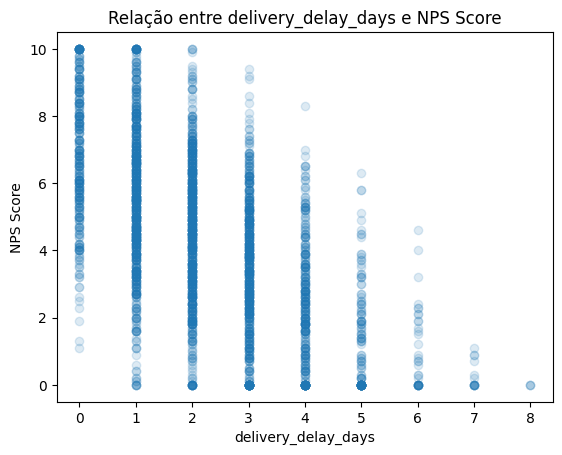

In [ ]:
# Função de relação com NPS Score

def plot_relation_nps(df, coluna):
    coluna= df[coluna]

    if pd.api.types.is_numeric_dtype(coluna):
        corr = df['nps_score'].corr(coluna).round(2)
        print(f'Correlação entre {coluna.name} e NPS Score: {corr}')
        plt.scatter(df[coluna.name], df['nps_score'], alpha=0.15)
        plt.title(f'Relação entre {coluna.name} e NPS Score')
        plt.xlabel(coluna.name)
        plt.ylabel('NPS Score')
        plt.show()

    else:
        df.groupby(coluna.name)['nps_score'].mean().plot(kind='bar')
        plt.title(f'Relação entre {coluna.name} e NPS Score')
        plt.xticks(rotation=45)
        plt.xlabel(coluna.name, rotation=0)
        plt.ylabel('Média do NPS Score')
        plt.show()

plot_relation_nps(df, 'delivery_delay_days')

Função de relação com NPS ->

- **`plot_relation_nps(df, coluna)`**: mostra como a variável se relaciona com `nps_score` -> correlação + scatter (numéricas) ou média de NPS por categoria (categóricas).

A partir daqui, cada variável é analisada chamando as duas funções em sequência, seguida de um markdown com a leitura de negócio do resultado.

### Logística

count    2500.000000
mean        8.022000
std         3.770411
min         2.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        14.000000
Name: delivery_time_days, dtype: float64


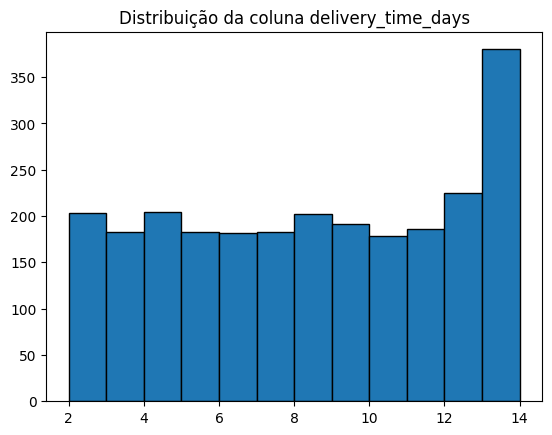

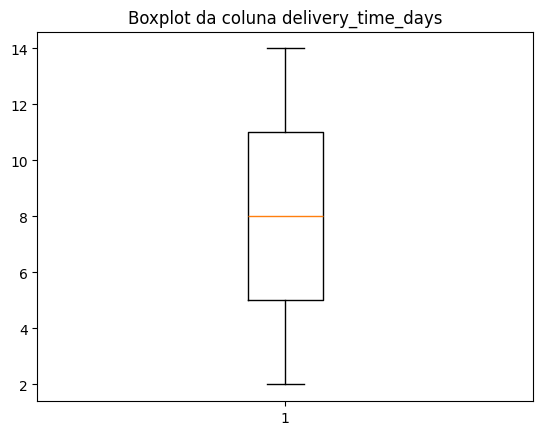

Correlação entre delivery_time_days e NPS Score: 0.0


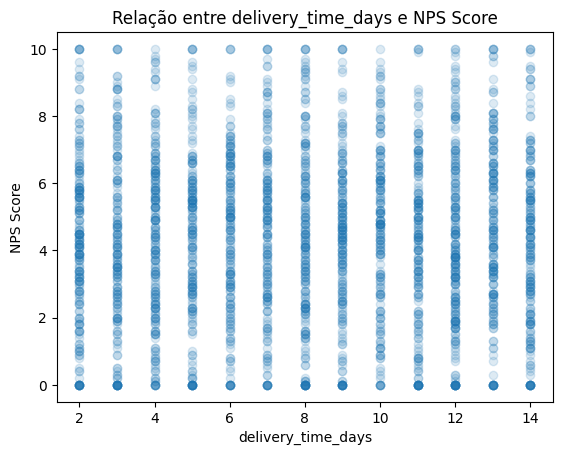

In [ ]:
plot_distribution(df, 'delivery_time_days')
plot_relation_nps(df, 'delivery_time_days')

count    2500.000000
mean        2.187200
std         1.454442
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: delivery_delay_days, dtype: float64


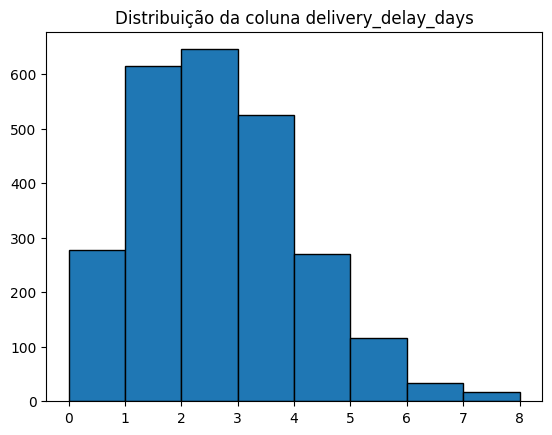

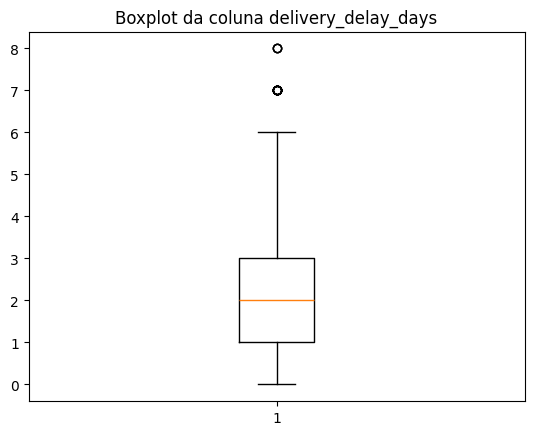

Correlação entre delivery_delay_days e NPS Score: -0.6


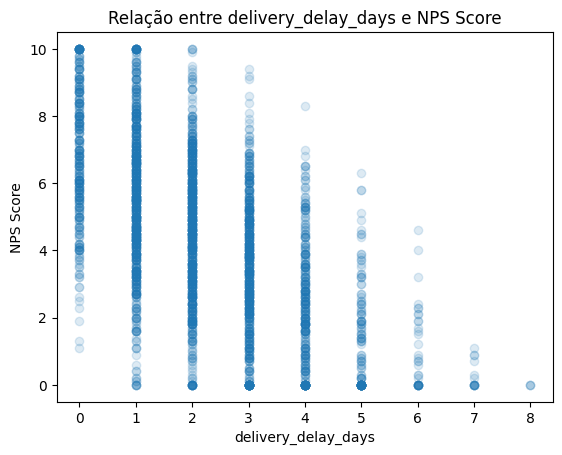

In [ ]:
plot_distribution(df, 'delivery_delay_days')
plot_relation_nps(df, 'delivery_delay_days')

count    2500.000000
mean        2.005600
std         0.815497
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: delivery_attempts, dtype: float64


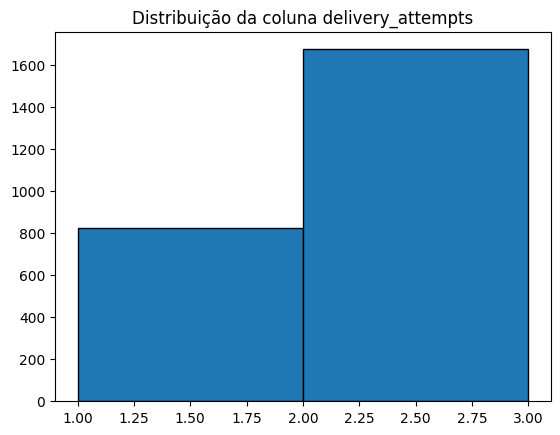

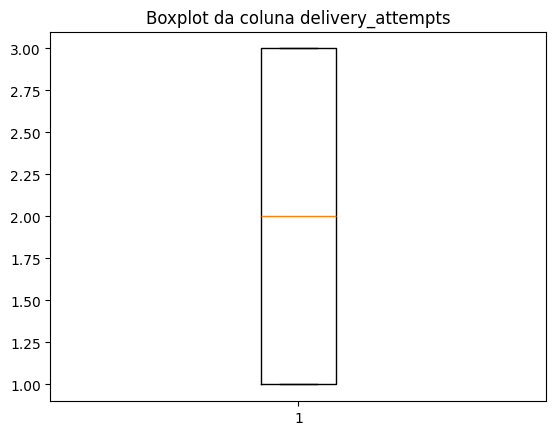

Correlação entre delivery_attempts e NPS Score: 0.03


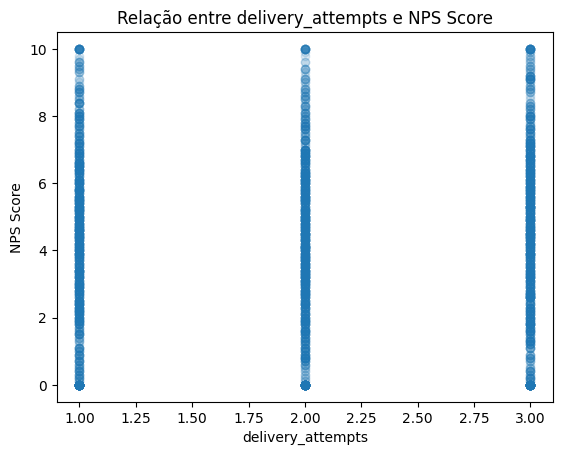

In [ ]:
plot_distribution(df, 'delivery_attempts')
plot_relation_nps(df, 'delivery_attempts')

In [ ]:
df.groupby('delivery_attempts')['nps_score'].mean()

delivery_attempts
1    4.353034
2    4.259905
3    4.522434
Name: nps_score, dtype: float64

count    2500.000000
mean       38.217016
std        12.076074
min         2.620000
25%        29.927500
50%        38.500000
75%        46.270000
max        76.130000
Name: freight_value, dtype: float64


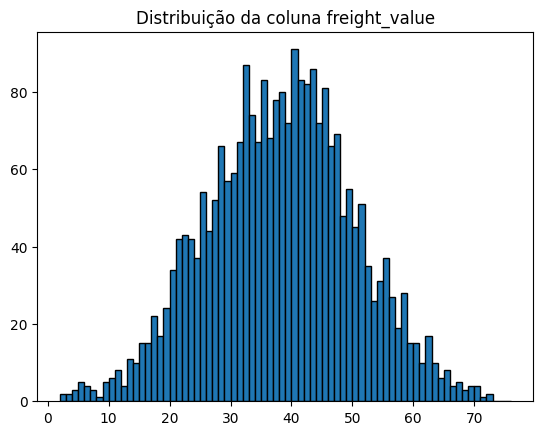

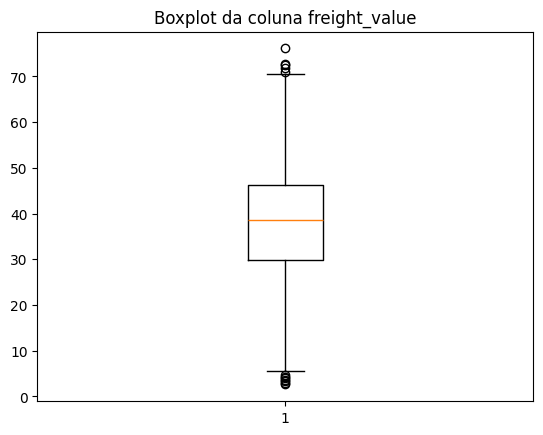

Correlação entre freight_value e NPS Score: -0.04


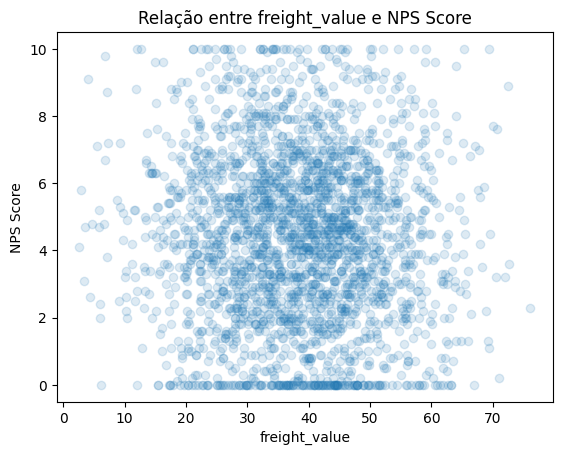

In [ ]:
plot_distribution(df, 'freight_value')
plot_relation_nps(df, 'freight_value')

In [ ]:
df['freight_ratio'] = df['freight_value'] / df['order_value']
df['nps_score'].corr(df['freight_ratio'])

np.float64(-0.06684969234992055)

Com a finalização dessa análise, foi possível identificar as correlações entre as variáveis logísticas e o NPS, além das distribuições de cada uma dentro do dataset.

Delivery Time Days → Média de 8 dias de entrega, variando de 2 a 14 dias, com correlação de 0,00 com o NPS. O cliente não demonstra insatisfação com o tempo de entrega em si, provavelmente porque já espera variação de prazo por motivos da compra tais como: frete econômico, produto pesado, produto importado etc.

Delivery Delay Days → Média de 2 dias de atraso, chegando a até 8 dias nos casos extremos, com correlação forte de -0,6 com o NPS. Diferente do tempo total, o atraso representa quebra de expectativa: o cliente não planejou para esse cenário, e é isso que gera insatisfação, não o prazo em si, mas o descumprimento dele.

Delivery Attempts → Correlação de 0,03, praticamente nula. Confirmamos com a média de NPS por número de tentativas (1: 4,35 / 2: 4,26 / 3: 4,52) os grupos são muito parecidos entre si, reforçando que o número de tentativas não é um fator relevante para a satisfação.

Freight Value → Testamos tanto o valor absoluto do frete (correlação de -0,04) quanto o frete relativo ao valor do pedido (-0,067, hipótese de que frete caro em pedido barato pesaria mais). Nenhuma das duas versões mostrou relação relevante com o NPS.

Conclusão: dentro do bloco logístico, o atraso é o único fator que realmente move a satisfação do cliente: tempo total, tentativas e frete não explicam a variação do NPS. Isso sugere que o investimento operacional deveria priorizar o cumprimento do prazo prometido, não necessariamente a redução do prazo em si. 

### Atendimento

count    2500.000000
mean        1.519600
std         1.231512
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: customer_service_contacts, dtype: float64


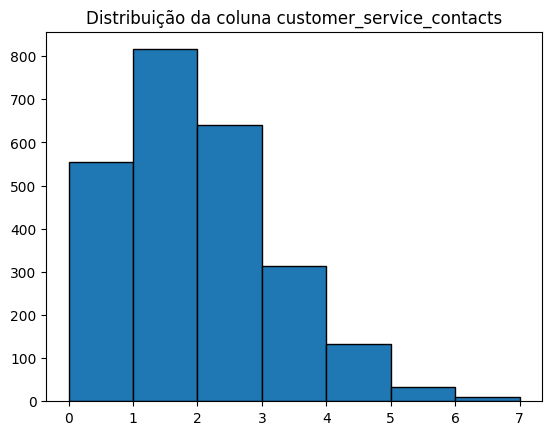

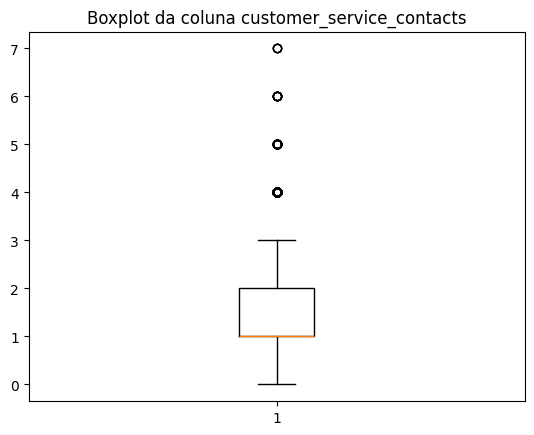

Correlação entre customer_service_contacts e NPS Score: -0.35


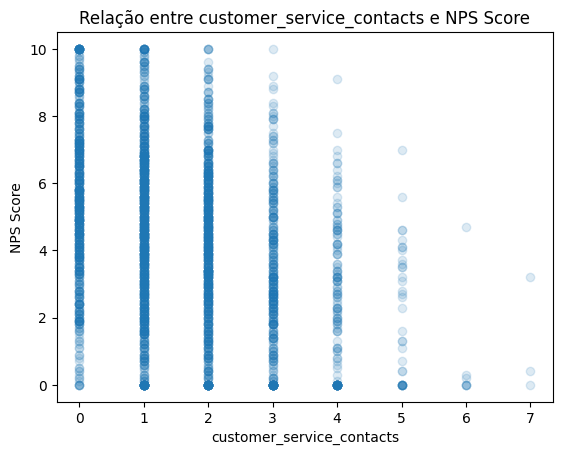

In [ ]:
plot_distribution(df, 'customer_service_contacts')
plot_relation_nps(df, 'customer_service_contacts')

In [ ]:
df.groupby('customer_service_contacts')['nps_score'].mean()

customer_service_contacts
0    5.543502
1    4.657108
2    4.116406
3    3.201911
4    2.654545
5    2.238235
6    0.742857
7    1.200000
Name: nps_score, dtype: float64

Quanto mais contato do cliente, pior é a média do NPS.

count    2500.000000
mean        5.485600
std         3.458002
min         0.000000
25%         2.000000
50%         6.000000
75%         8.000000
max        11.000000
Name: resolution_time_days, dtype: float64


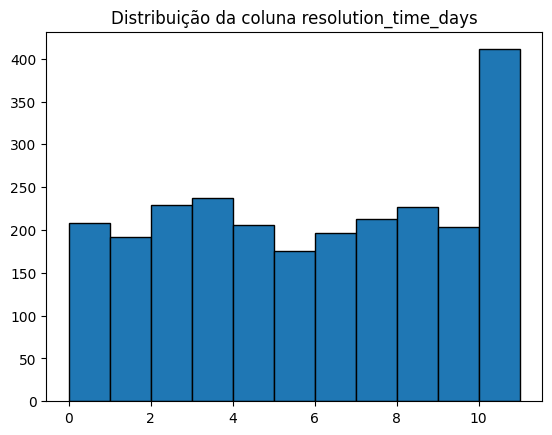

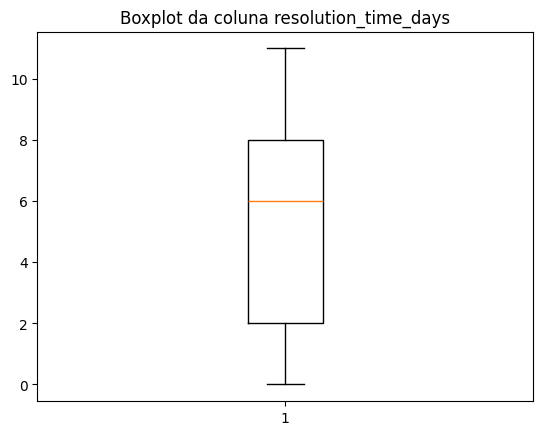

Correlação entre resolution_time_days e NPS Score: -0.19


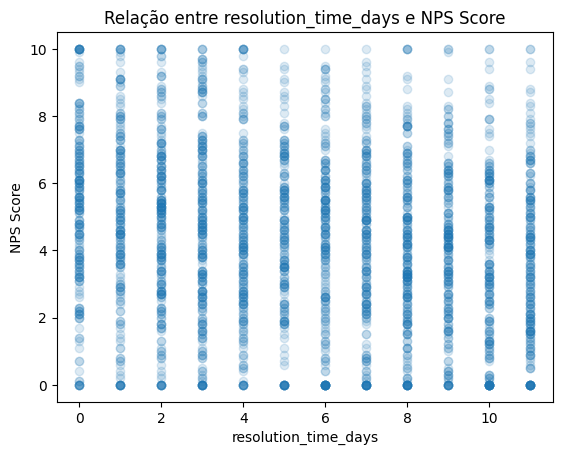

In [ ]:
plot_distribution(df, 'resolution_time_days')
plot_relation_nps(df, 'resolution_time_days')

In [ ]:
df.loc[df['customer_service_contacts']== 0, 'resolution_time_days'].describe()

count    554.000000
mean       5.534296
std        3.337509
min        0.000000
25%        3.000000
50%        6.000000
75%        8.000000
max       11.000000
Name: resolution_time_days, dtype: float64

Apenas uma comprovação do que haviamos comentado no bloco de data quality, são 554 casos que não tiveram contato e mesmo assim consta como uma média de 5 dias para resolução da reclamação.

count    2500.000000
mean        4.150400
std         1.784223
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        11.000000
Name: complaints_count, dtype: float64


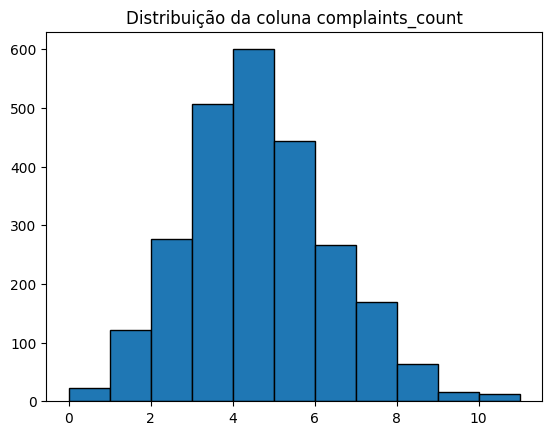

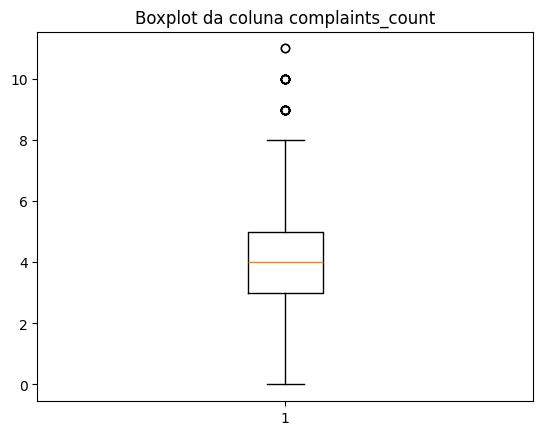

Correlação entre complaints_count e NPS Score: -0.5


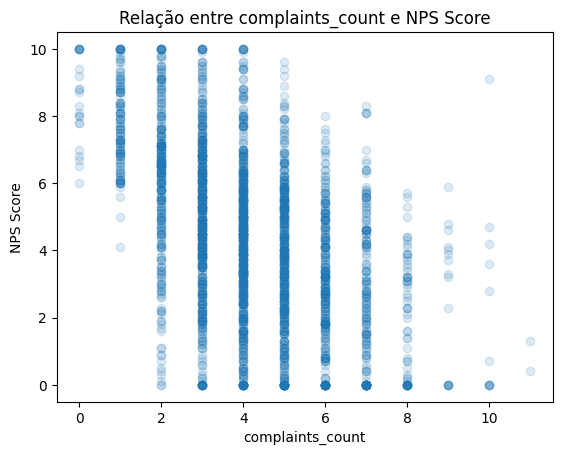

In [ ]:
plot_distribution(df, 'complaints_count')
plot_relation_nps(df, 'complaints_count')

Com a finalização dessa análise, foi possível identificar as correlações entre as variáveis de atendimento e o NPS, além das distribuições de cada uma dentro do dataset.

**Customer Service Contacts** → Temos uma média de 1,51 contatos por atendimento e uma correlação de -0,35 com a nota do NPS. Abrindo mais a visão dessa variável, conseguimos enxergar uma escada de NPS médio: a cada contato a mais do cliente, existe uma redução de quase 1 ponto no NPS.

**Resolution Time Days** → Temos uma média de 5,48 dias para a resolução das reclamações feitas pelos clientes, alcançando 11 dias nos casos extremos, causando frustração ao cliente e registrando uma correlação de -0,19 com o NPS. Aliás, temos um gap dentro do nosso dataset, mostrando que clientes com 0 contatos possuem uma média de 5,53 dias para resolução dos casos o mesmo padrão de inconsistência já documentado no capítulo de Data Quality (colunas geradas sem dependência lógica entre si). Isso provavelmente explica por que essa é a correlação mais fraca das três do bloco: parte do sinal está diluído por tempos de resolução que não deveriam existir.

**Complaints** → Nessa análise temos a visualização sobre as reclamações dos clientes: uma média de 4,15 reclamações por pedido e uma correlação de -0,5 entre reclamação e NPS. O gráfico de dispersão mostra uma relação forte: quanto mais reclamações, menor o NPS.

Concluímos então que, dentro do bloco de atendimento, todas as variáveis acabam impactando o NPS. Diferente do bloco de Logística, onde só o atraso se mostrou relevante, aqui todas as variáveis de atendimento impactam a satisfação, o que sugere que a experiência de suporte, como um todo, é uma área mais sensível para o cliente do que a operação logística isolada. Isso sugere que o investimento operacional deveria priorizar a resolução rápida e eficaz das reclamações e contatos dos clientes.

### Pedido / Pricing

count    2500.000000
mean      434.259740
std       289.772497
min         7.760000
25%       220.245000
50%       375.515000
75%       577.290000
max      1983.810000
Name: order_value, dtype: float64


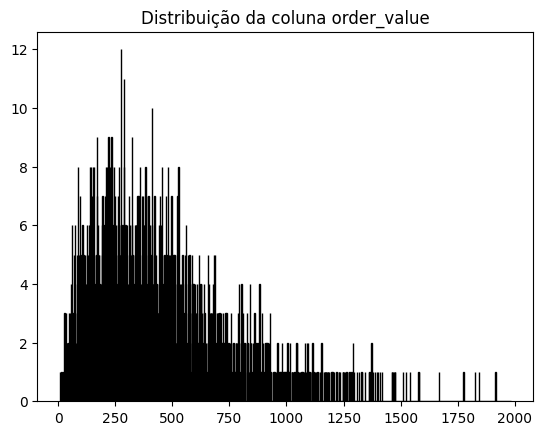

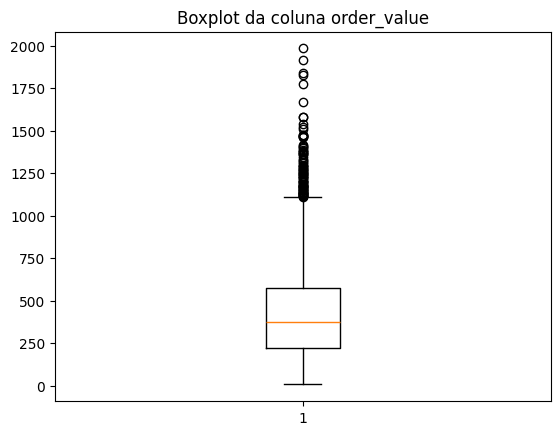

Correlação entre order_value e NPS Score: 0.04


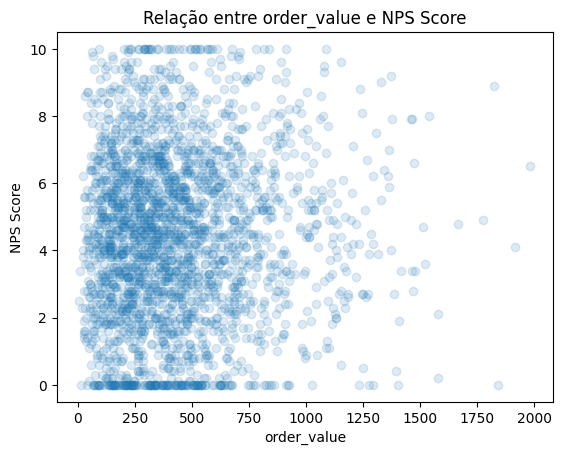

In [ ]:
plot_distribution(df, 'order_value')
plot_relation_nps(df, 'order_value')

count    2500.000000
mean       29.745620
std        29.225603
min         0.020000
25%         8.885000
50%        20.935000
75%        40.832500
max       230.330000
Name: discount_value, dtype: float64


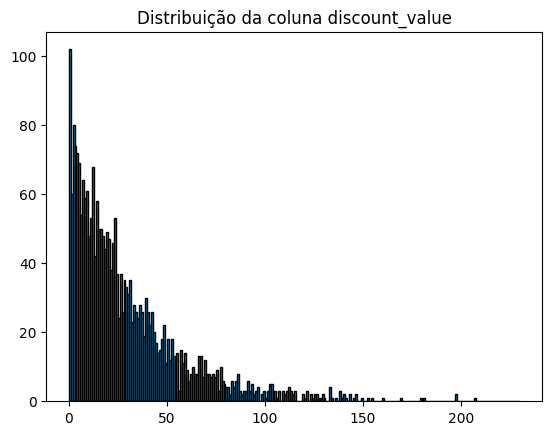

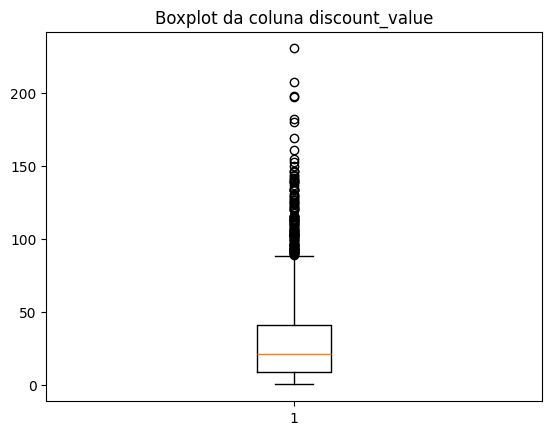

Correlação entre discount_value e NPS Score: 0.03


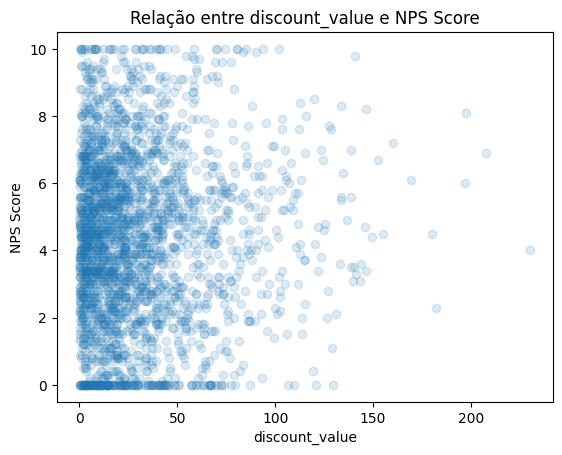

In [ ]:
plot_distribution(df, 'discount_value')
plot_relation_nps(df, 'discount_value')

count    2500.000000
mean        6.004000
std         3.159743
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        11.000000
Name: payment_installments, dtype: float64


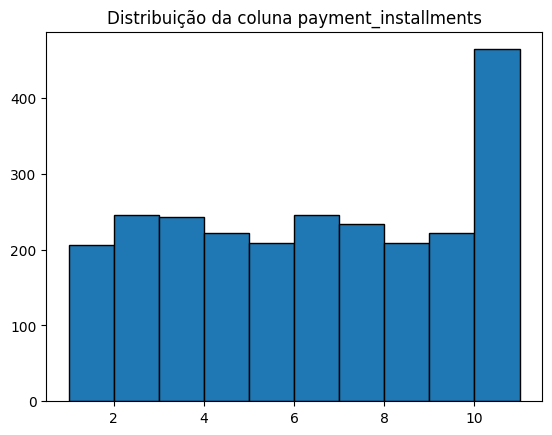

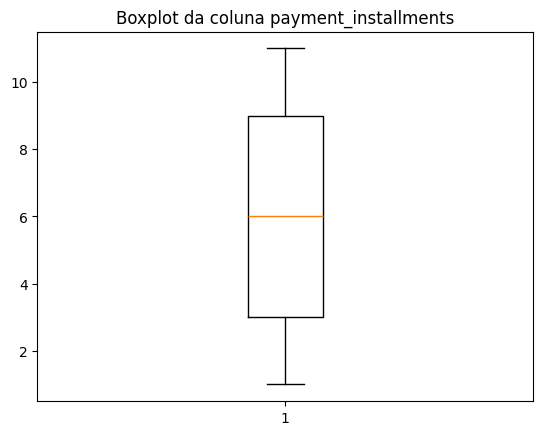

Correlação entre payment_installments e NPS Score: 0.02


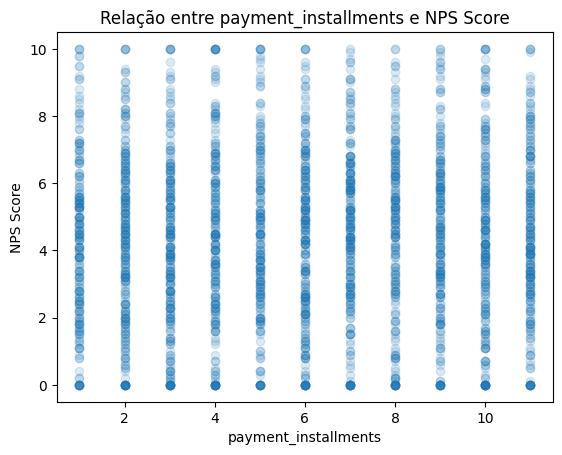

In [ ]:
plot_distribution(df, 'payment_installments')
plot_relation_nps(df, 'payment_installments')

count    2500.000000
mean        3.470800
std         1.687331
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: items_quantity, dtype: float64


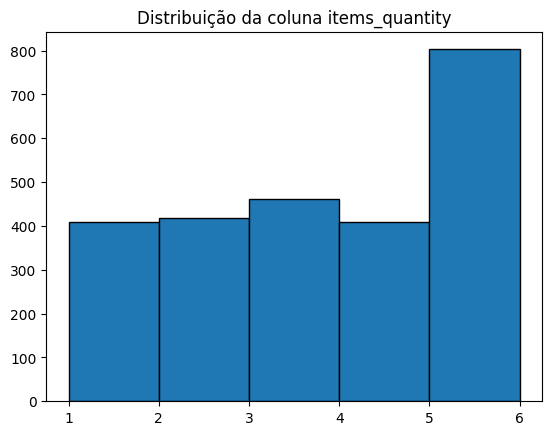

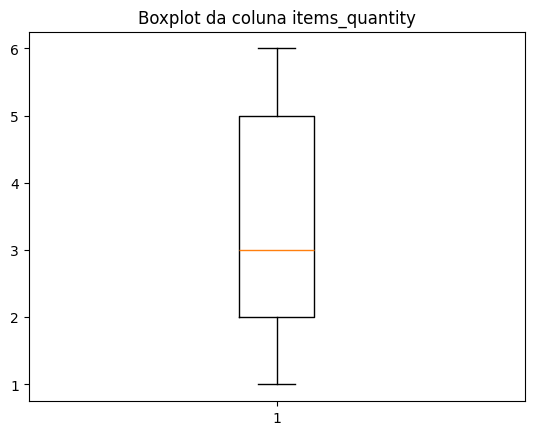

Correlação entre items_quantity e NPS Score: 0.01


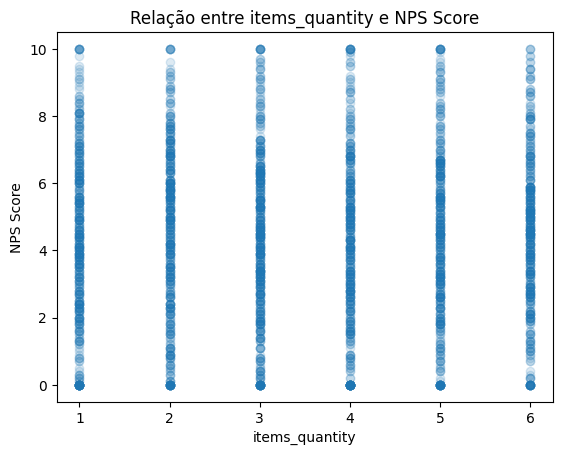

In [ ]:
plot_distribution(df, 'items_quantity')
plot_relation_nps(df, 'items_quantity')

In [ ]:
df['discount_ratio'] = df['discount_value'] / df['order_value']
df['nps_score'].corr(df['discount_ratio'])

np.float64(-0.009399326529745596)

Com a finalização dessa análise, foi possível identificar que preço, desconto, quantidade de itens e parcelamento não têm correlação relevante com o NPS: todas as correlações ficaram abaixo de 0,04 em módulo 

- `order_value`: 0,037
- `items_quantity`: 0,011
- `discount_value`: 0,025
- `payment_installments`: 0,024

Isso mostra que o cliente não está se tornando detrator por causa do **preço** do produto, e sim por questões de **pós-compra**: logística (especificamente o atraso) e atendimento (contatos repetidos e reclamações), como já vimos nos blocos anteriores. Isso reforça que o investimento operacional deve continuar priorizado em cumprimento de prazo e resolução rápida no atendimento, não em política comercial (preço, desconto ou parcelamento).

### Perfil do cliente

count    2500.000000
mean       43.396000
std        14.888487
min        18.000000
25%        31.000000
50%        43.000000
75%        56.000000
max        69.000000
Name: customer_age, dtype: float64


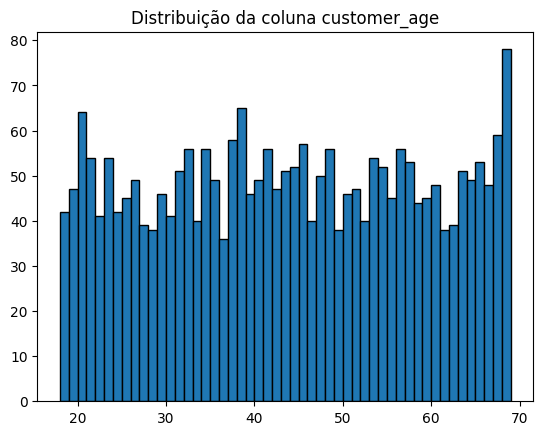

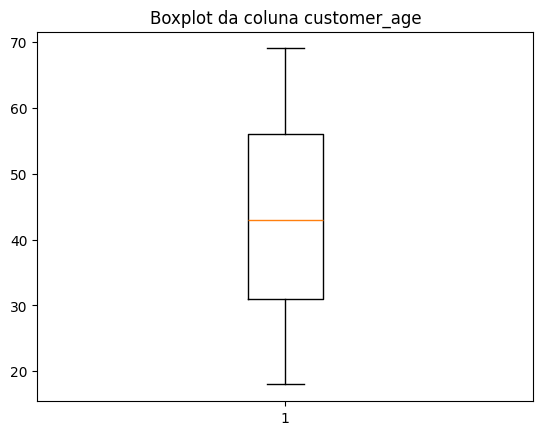

Correlação entre customer_age e NPS Score: -0.01


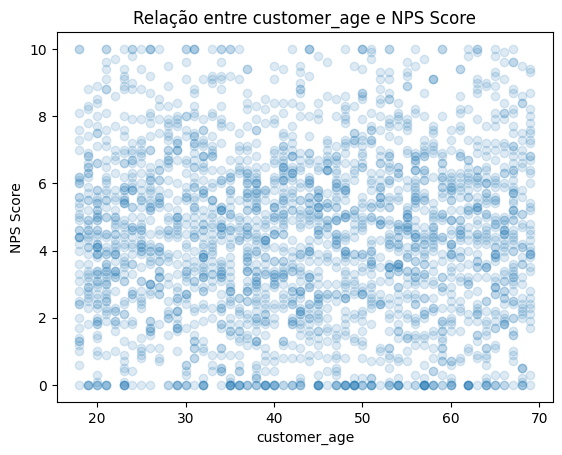

In [ ]:
plot_distribution(df, 'customer_age')
plot_relation_nps(df, 'customer_age')

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64


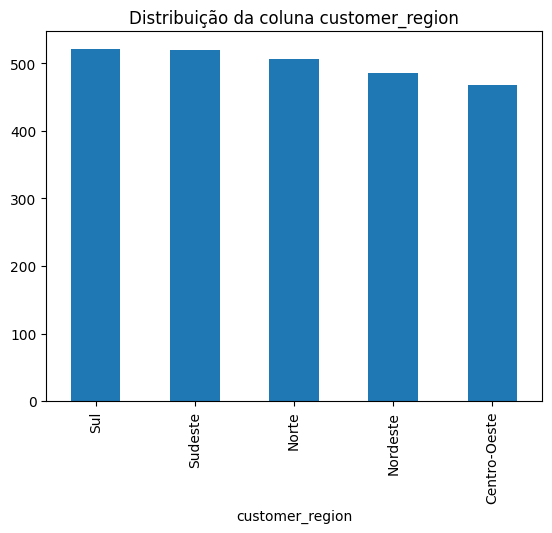

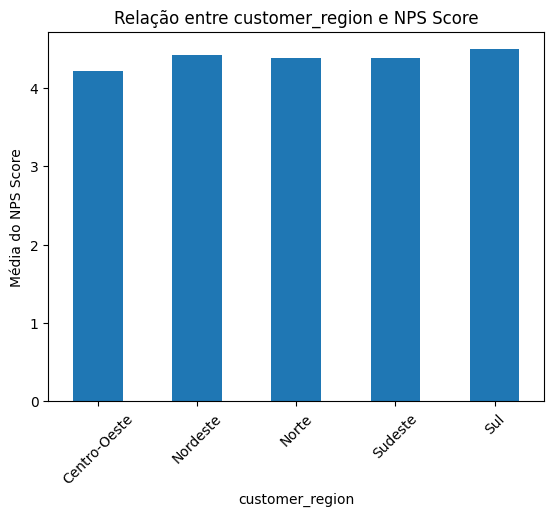

In [ ]:
plot_distribution(df, 'customer_region')
plot_relation_nps(df, 'customer_region')

In [ ]:
regiaoXfrete = df.groupby('customer_region')['freight_value'].mean()
regiaoXdelay = df.groupby('customer_region')['delivery_delay_days'].mean()

regiaoXfrete

customer_region
Centro-Oeste    37.872329
Nordeste        37.254887
Norte           38.975079
Sudeste         38.504442
Sul             38.399175
Name: freight_value, dtype: float64

In [ ]:
regiaoXdelay

customer_region
Centro-Oeste    2.222222
Nordeste        2.185567
Norte           2.144269
Sudeste         2.217308
Sul             2.168906
Name: delivery_delay_days, dtype: float64

count    2500.000000
mean       61.322400
std        34.478729
min         1.000000
25%        31.000000
50%        62.000000
75%        91.000000
max       119.000000
Name: customer_tenure_months, dtype: float64


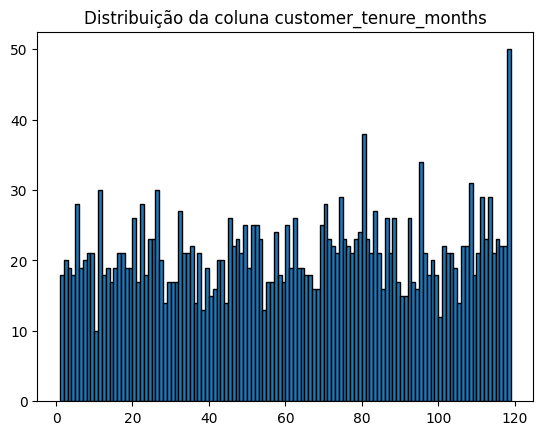

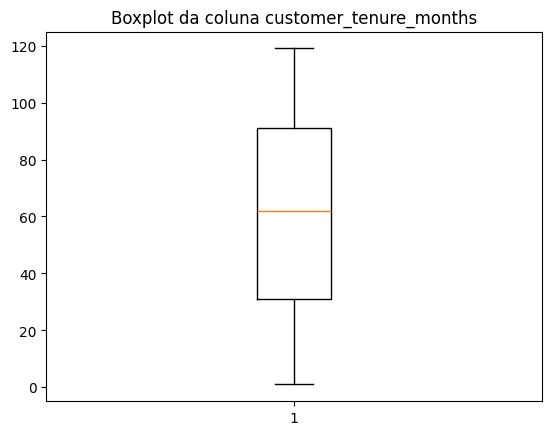

Correlação entre customer_tenure_months e NPS Score: -0.01


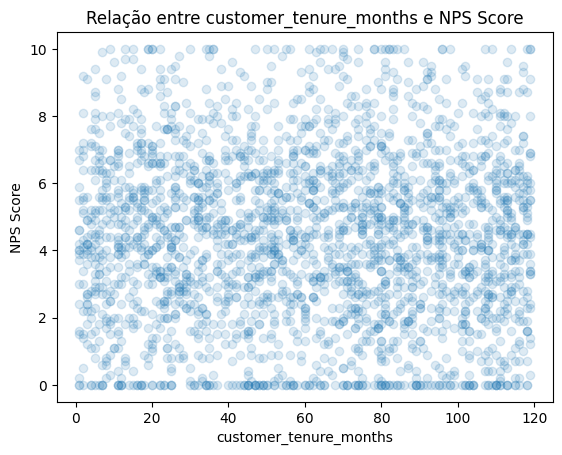

In [ ]:
plot_distribution(df, 'customer_tenure_months')
plot_relation_nps(df, 'customer_tenure_months')

In [ ]:
df.groupby('customer_tenure_months')['nps_score'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_tenure_months,,,,,,,,
1,18.0,3.488889,2.173609,0.0,1.800,3.95,4.600,7.0
2,20.0,4.520000,2.561989,0.0,2.800,4.70,6.500,9.2
3,19.0,3.736842,1.759170,1.2,2.500,3.90,4.300,9.1
4,18.0,3.850000,2.387282,0.0,2.050,4.05,5.150,7.6
5,28.0,4.746429,2.595649,0.0,2.875,4.45,6.800,9.4
...,...,...,...,...,...,...,...,...
115,23.0,3.813043,2.348559,0.0,2.250,3.90,5.750,8.0
116,22.0,3.909091,2.523397,0.0,1.950,3.55,6.150,8.7
117,22.0,5.363636,2.286304,1.0,4.200,5.30,6.950,9.5


In [ ]:
bins = [0, 12, 36, 60, 90, 120]
labels = ['0-12', '12-36', '36-60', '60-90', '90-119']
df['tenure_bin'] = pd.cut(df['customer_tenure_months'], bins=bins, labels=labels, include_lowest=True)
df.groupby('tenure_bin')['nps_score'].mean()

tenure_bin
0-12      4.145455
12-36     4.551633
36-60     4.296862
60-90     4.416893
90-119    4.355183
Name: nps_score, dtype: float64

Com a finalização dessa análise, foi possível identificar que idade (correlação de -0,01) e tenure (correlação de -0,01, sem tendência mesmo agrupando por faixas) têm relação praticamente nula com o NPS. 

Região também não mostra diferença relevante: a variação entre a média de NPS da melhor região (Sul, 4,49) e da pior (Centro-Oeste, 4,21) é de apenas 0,28 pontos.

Nenhuma variável de perfil explica a variação do NPS. Diferente do bloco de Atendimento (onde tudo importa) e de Logística (onde só o atraso importa), aqui é como no bloco de Pedido/Pricing: nada importa.

Testamos ainda a hipótese de que a região poderia ser um proxy escondido: clientes de certas regiões tendo frete mais caro ou atraso maior, e isso (não a região em si) explicando a diferença de NPS. Comparando a média de frete e de atraso por região, os valores são praticamente idênticos entre todas as cinco regiões, então a hipótese caiu por terra: região não influencia o NPS nem diretamente, nem como proxy de logística.

Concluímos então que a satisfação do cliente não depende de quem ele é (idade, região, tempo de casa), e sim do que a empresa faz na operação de cada pedido, no caso: entrega no prazo e atendimento resolutivo. Isso reforça que o foco de ação deve continuar em execução operacional, não em segmentação de perfil de cliente.

### Avaliações internas -> CSAT & Recompra

In [ ]:
df['nps_score'].corr(df['csat_internal_score'])

np.float64(0.56395226187909)

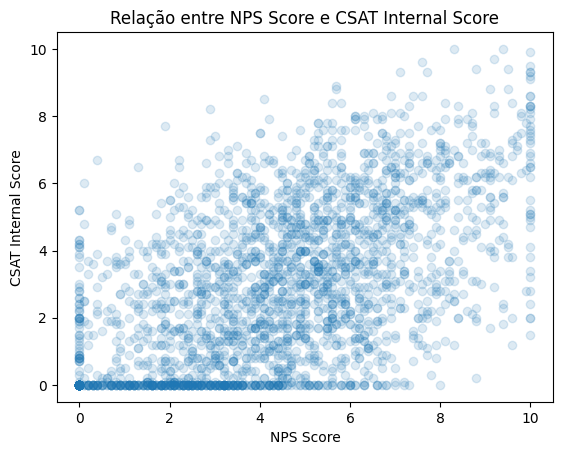

In [ ]:
plt.scatter(df['nps_score'], df['csat_internal_score'], alpha=0.15)
plt.title('Relação entre NPS Score e CSAT Internal Score')
plt.xlabel('NPS Score')
plt.ylabel('CSAT Internal Score')
plt.show()

In [ ]:
df.groupby('repeat_purchase_30d')['nps_score'].mean()

repeat_purchase_30d
0    3.936196
1    9.009633
Name: nps_score, dtype: float64

In [ ]:
(df['csat_internal_score'] == 0).sum() / df.shape[0] * 100

np.float64(18.48)

In [ ]:
df['repeat_purchase_30d'].value_counts()

repeat_purchase_30d
0    2282
1     218
Name: count, dtype: int64

Com a finalização dessa análise, foi possível avaliar duas métricas internas que não são fatores operacionais em si, e por isso não entram no ranking do próximo capítulo. 

Servem a propósitos diferentes: checar consistência entre métricas de satisfação (CSAT) e observar uma consequência do NPS, não uma causa (recompra).

**CSAT Internal Score** → A correlação com `nps_score` é de 0,56 = moderada a forte, mostrando que as duas métricas de satisfação, em geral, concordam entre si. Porém, o scatter revela uma faixa de pontos concentrada em `csat_internal_score = 0`, espalhada por quase toda a faixa de NPS: são 462 registros (18,5% da base) nessa condição, e mesmo dentro desse grupo o NPS varia bastante (de 0 a 8). Isso sugere que existe uma fatia relevante da base onde o CSAT interno não está capturando a experiência do cliente da mesma forma que o NPS.

**Repeat Purchase 30d** → Diferente das demais variáveis analisadas, essa não é testada como possível causa do NPS, é leakage (não está disponível no momento em que a previsão precisaria ser feita) e representa uma consequência do NPS, não uma explicação para ele. Comparando a média de NPS entre quem recomprou e quem não recomprou em 30 dias: 

- Recomprou em 30 dias -> NPS médio de 9,01
- Não recomprou em 30 dias -> NPS médio de 3,94

Vale registrar que os grupos são desbalanceados (apenas 218 dos 2500 clientes, 8,7%, recompraram nesse período), mas a diferença é grande demais para ser explicada só pelo tamanho da amostra. 

Esse resultado responde diretamente à pergunta de negócio da Fase 1 sobre como o NPS impacta a recompra: promotores recompram muito mais que detratores, confirmando que a satisfação medida pelo NPS tem relação direta com a retenção do cliente.

## 2. Fatores críticos mais críticos para a satisfação

In [ ]:
colunas = [
    # Logística
    'delivery_time_days',
    'delivery_delay_days',
    'delivery_attempts',
    'freight_value',
    'freight_ratio',

    # Atendimento
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',

    # Pedido / Pricing
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'discount_ratio',

    # Perfil
    'customer_age',
    'customer_tenure_months',
]

In [ ]:
correlacoes = {} # Dicionário

for item in colunas: # Loop para verificar as correlações no dicionário de correlações
    correlacao = df['nps_score'].corr(df[item])
    correlacoes[item] = correlacao

correlacoes

{'delivery_time_days': np.float64(0.0009249524195083521),
 'delivery_delay_days': np.float64(-0.5972599425164119),
 'delivery_attempts': np.float64(0.02767962859303966),
 'freight_value': np.float64(-0.04108718993080976),
 'freight_ratio': np.float64(-0.06684969234992055),
 'customer_service_contacts': np.float64(-0.3508449560392687),
 'resolution_time_days': np.float64(-0.19139177304054514),
 'complaints_count': np.float64(-0.4967997342016231),
 'order_value': np.float64(0.03699028431097176),
 'items_quantity': np.float64(0.011468195894643015),
 'discount_value': np.float64(0.025103579685508432),
 'payment_installments': np.float64(0.02371765546172465),
 'discount_ratio': np.float64(-0.009399326529745596),
 'customer_age': np.float64(-0.009936291558880013),
 'customer_tenure_months': np.float64(-0.009711398994148683)}

In [ ]:
ordem_correlacoes = pd.Series(correlacoes).abs().sort_values(ascending=True).index
ranking = pd.Series(correlacoes).reindex(ordem_correlacoes)
ranking

delivery_time_days           0.000925
discount_ratio              -0.009399
customer_tenure_months      -0.009711
customer_age                -0.009936
items_quantity               0.011468
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
freight_value               -0.041087
freight_ratio               -0.066850
resolution_time_days        -0.191392
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
dtype: float64

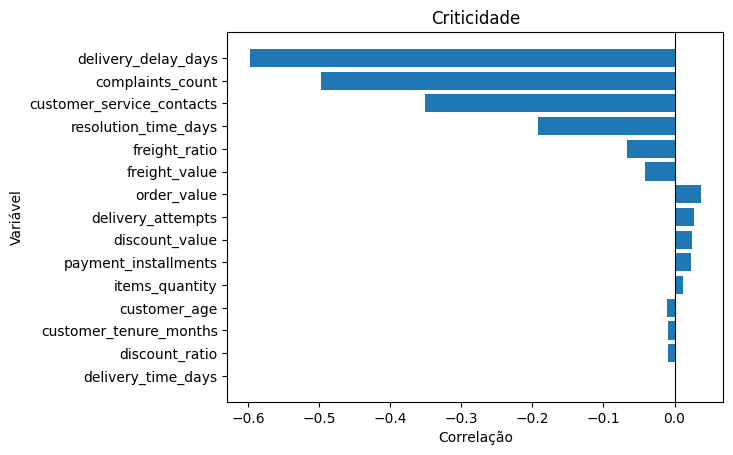

In [ ]:
# Plotando gráficos para avaliar criticidade

plt.barh(ranking.index, ranking.values)
plt.title('Criticidade')
plt.xlabel('Correlação')
plt.ylabel('Variável')
plt.axvline(0, color='Black', linewidth=0.8)
plt.show()

Com a finalização da nossa análise de correlação das variáveis com o NPS, temos o gráfico mostrando que apenas 4 variáveis das 15 testadas têm correlação relevante. A correlação com sinal negativo mostra uma relação inversa (quando uma sobe, a outra desce), quanto mais o `delivery_delay_days` sobe, mais o NPS desce, por isso a correlação é negativa.

**Ordem de criticidade**

1. `delivery_delay_days` — correlação de -0,60 com o NPS
2. `complaints_count` — correlação de -0,50 com o NPS
3. `customer_service_contacts` — correlação de -0,35 com o NPS
4. `resolution_time_days` — correlação de -0,19 com o NPS

Essas são as variáveis prioritárias para atuação a partir deste estudo.

O padrão observado é que as variáveis mais fortes se concentram em dois blocos:
- Logística (apenas o atraso)
- Atendimento (todas as variáveis) 

e nenhuma variável de preço ou de perfil aparece no topo.

## 3. O que gera detratores

In [ ]:
# Definição de Promotor, neutro e detrator

def classificao(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(classificao)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,freight_ratio,discount_ratio,tenure_bin,nps_categoria
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,0,4,6.9,0,3,6.5,0.397409,0.281615,12-36,Detrator
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,0,10,2.4,0,3,0.0,0.061510,0.020721,0-12,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,4,5,4.8,0,7,1.5,0.080839,0.084448,90-119,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,1,11,5.9,0,4,0.3,0.116615,0.064794,90-119,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,1,0,6.1,0,3,7.9,0.155378,0.116059,36-60,Detrator


In [ ]:
share = df['nps_categoria'].value_counts(normalize=True)*100
absoluto = df['nps_categoria'].value_counts()

nps_categoria
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

In [ ]:
share

nps_categoria
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64

In [ ]:
absoluto

nps_categoria
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

In [ ]:
nps_geral = share['Promotor'] - share['Detrator']
nps_geral

np.float64(-79.96)

In [ ]:
colunas_detratores = [
        'delivery_delay_days',
        'complaints_count',
        'customer_service_contacts',
        'resolution_time_days'
]

In [ ]:
df.groupby('nps_categoria')[colunas_detratores].mean()

,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days
nps_categoria,,,,
Detrator,2.414889,4.442390,1.632053,5.694642
Neutro,1.053381,2.693950,1.007117,4.615658
Promotor,0.718182,2.272727,0.672727,3.700000


C:\Users\ruani\AppData\Local\Temp\ipykernel_28096\3687443264.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=['Detrator', 'Neutro', 'Promotor'])


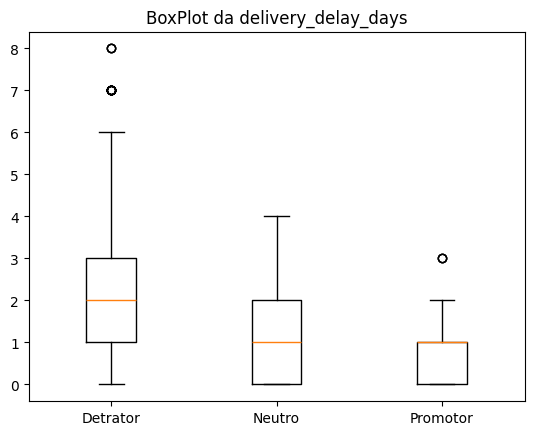

C:\Users\ruani\AppData\Local\Temp\ipykernel_28096\3687443264.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=['Detrator', 'Neutro', 'Promotor'])


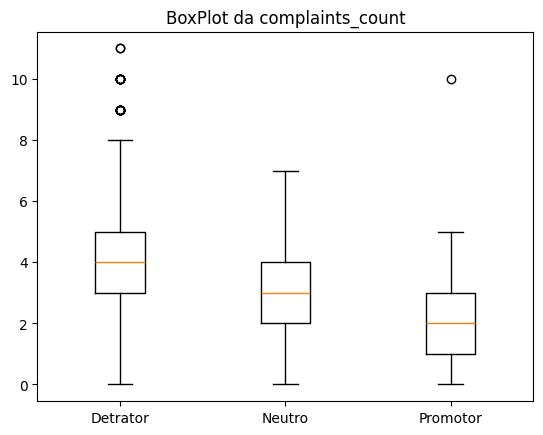

C:\Users\ruani\AppData\Local\Temp\ipykernel_28096\3687443264.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=['Detrator', 'Neutro', 'Promotor'])


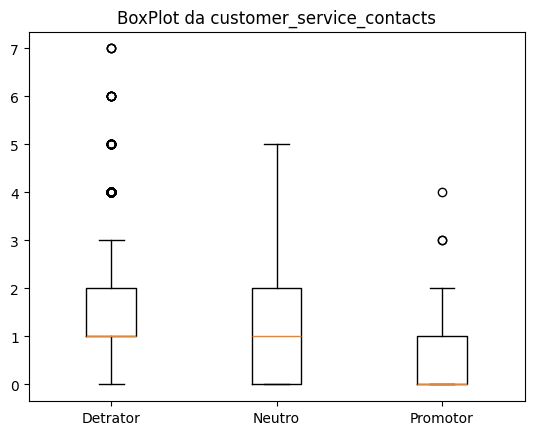

C:\Users\ruani\AppData\Local\Temp\ipykernel_28096\3687443264.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=['Detrator', 'Neutro', 'Promotor'])


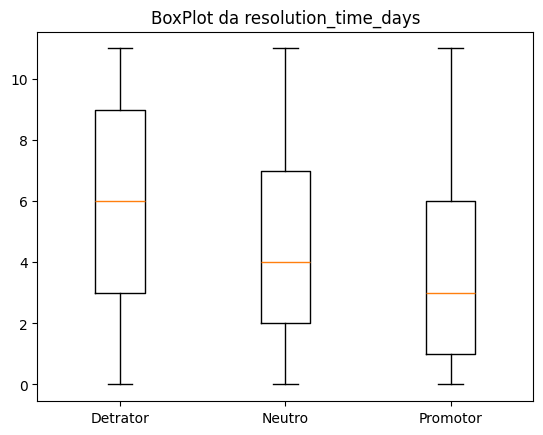

In [ ]:
def box_plot (df, coluna):
    detrator = df[df['nps_categoria'] == 'Detrator'][coluna]
    neutro = df[df['nps_categoria'] == 'Neutro'][coluna]
    promotor = df[df['nps_categoria'] == 'Promotor'][coluna]

    dados = [detrator, neutro, promotor]

    plt.boxplot(dados, labels=['Detrator', 'Neutro', 'Promotor'])
    plt.title(f'BoxPlot da {coluna}')
    plt.show()

box_plot(df, 'delivery_delay_days')
box_plot(df, 'complaints_count')
box_plot(df, 'customer_service_contacts')
box_plot(df, 'resolution_time_days')

Com a finalização da análise do que gera os detratores, conseguimos identificar que 84,36% da nossa base de dados é detratora (2109 detratores), com uma nota geral de NPS de -79,96.

**A separação das 4 variáveis por grupo:**

- **Delivery Delay Days** → Detratores possuem 2,41 dias de atraso e Promotores possuem 0,71 dias, ou seja, detratores esperam mais de 3x o atraso de um promotor.
- **Complaints** → Detratores possuem uma média de 4,44 reclamações e promotores possuem uma média de 2,27, ou seja, quase o dobro de reclamações.
- **Customer Service Contacts** → Detratores possuem uma média de 1,63 contatos com o suporte e promotores possuem uma média de 0,67, ou seja, mais que o dobro de contatos.
- **Resolution Time Days** → Detratores possuem uma média de 5,69 dias para resolução e Promotores possuem uma média de 3,7 dias para a resolução de algum problema, cerca de 1,5x mais devagar.

**Dentro dos gráficos, conseguimos observar diferentes níveis de separação entre os grupos:**

- **Delivery Delay Days** → a separação entre os três grupos é a mais nítida das quatro variáveis: as caixas quase não se sobrepõem, e o grupo Promotor fica bem concentrado perto de zero dias de atraso. É a variável que melhor diferencia um cliente detrator de um promotor olhando individualmente.
- **Complaints Count** → separação ainda visível, mas com mais sobreposição entre os grupos Neutro e Promotor do que no atraso.
- **Customer Service Contacts** → aqui a sobreposição é bem maior: Detrator e Neutro têm a mesma mediana (1 contato) e caixas quase idênticas. A diferença de médias existe, mas essa variável sozinha não separa bem os grupos no nível individual.
- **Resolution Time Days** → é a variável com mais sobreposição entre as três categorias. Isso é coerente com o problema de qualidade de dado identificado antes (tempos de resolução registrados mesmo para clientes sem nenhum contato), que dilui a capacidade dessa variável de diferenciar detratores de promotores.

**Outliers** → Dentro da base de dados temos alguns outliers, por exemplo: Promotor com muitas reclamações e também contatos com o suporte, existem exceções, clientes com bastante fricção operacional que ainda assim viraram promotores, então a regra geral não é absoluta.

**Concluindo**, tanto a correlação (capítulo 2) quanto a comparação por grupo (capítulo 3) apontam consistentemente para os mesmos quatro fatores: atraso na entrega, número de reclamações, contatos com o atendimento e tempo de resolução. São duas formas diferentes de olhar os dados, uma medindo a força da relação linear com o NPS, outra comparando o perfil médio de cada grupo e ambas convergem para a mesma resposta, o que reforça a confiabilidade do achado.

Respondendo diretamente à pergunta deste capítulo: o que mais gera detratores é a experiência de pós-venda malsucedida:
- Atraso nas entregas dos pedidos
- Multiplos contatos para resolução dos problemas
- Morosidade na resolução do problema 

Não é o perfil do cliente, nem o valor do pedido, nem o preço e sim a execução operacional de cada compra.

Agora entraremos na avalição de, em qual momento que o nosso cliente "vira a chave" e se torna um detrator quase de uma forma certa?

## 4. Ponto de ruptura na experiência

In [ ]:
df['is_detrator'] = df['nps_categoria'] == 'Detrator'

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,freight_ratio,discount_ratio,tenure_bin,nps_categoria,is_detrator
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,0.397409,0.281615,12-36,Detrator,True
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,0.061510,0.020721,0-12,Detrator,True
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,0.080839,0.084448,90-119,Detrator,True
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,0.116615,0.064794,90-119,Detrator,True
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,0.155378,0.116059,36-60,Detrator,True


In [ ]:
df.groupby('delivery_delay_days')['is_detrator'].mean()

delivery_delay_days
0    0.516245
1    0.739837
2    0.879257
3    0.967619
4    0.992593
5    1.000000
6    1.000000
7    1.000000
8    1.000000
Name: is_detrator, dtype: float64

In [ ]:
df.groupby('complaints_count')['is_detrator'].mean()

complaints_count
0     0.173913
1     0.303279
2     0.653430
3     0.816568
4     0.898333
5     0.945946
6     0.973684
7     0.970414
8     1.000000
9     1.000000
10    0.909091
11    1.000000
Name: is_detrator, dtype: float64

In [ ]:
df.groupby('customer_service_contacts')['is_detrator'].mean()

customer_service_contacts
0    0.707581
1    0.839461
2    0.885938
3    0.933121
4    0.977273
5    0.970588
6    1.000000
7    1.000000
Name: is_detrator, dtype: float64

In [ ]:
df.groupby('resolution_time_days')['is_detrator'].mean()

resolution_time_days
0     0.750000
1     0.760417
2     0.816594
3     0.780591
4     0.849515
5     0.857955
6     0.852792
7     0.859155
8     0.889868
9     0.882353
10    0.918782
11    0.911215
Name: is_detrator, dtype: float64

In [ ]:
def plot_linhas(df, coluna):
    pct_detratores = df.groupby(coluna)['is_detrator'].mean()*100

    plt.plot(pct_detratores.index, pct_detratores.values, marker='o')
    plt.title(f'Percentual de detratores da variável {coluna}')
    plt.xlabel(f'{coluna}')
    plt.ylabel('Percentual de detratores (%)')
    plt.show()

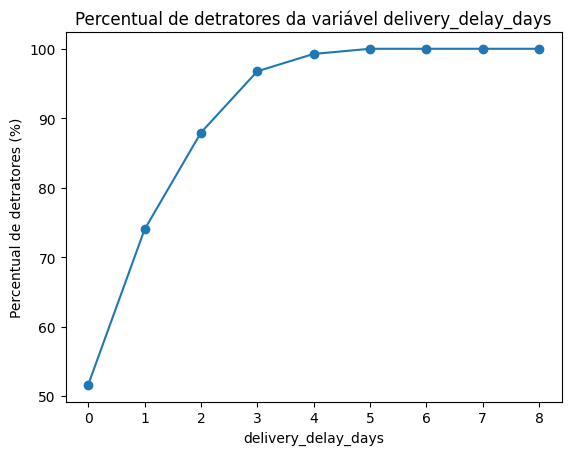

In [ ]:
plot_linhas(df, 'delivery_delay_days')

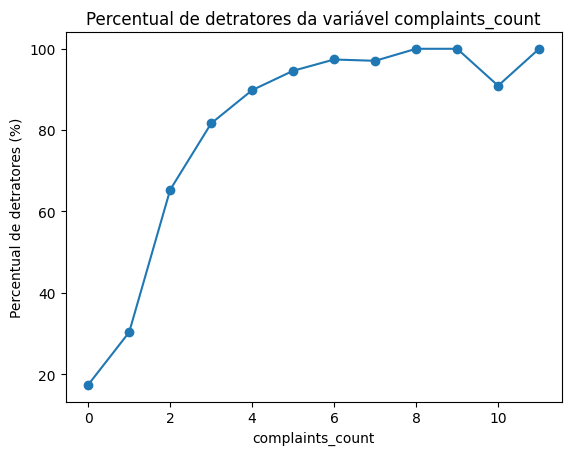

In [ ]:
plot_linhas(df, 'complaints_count')

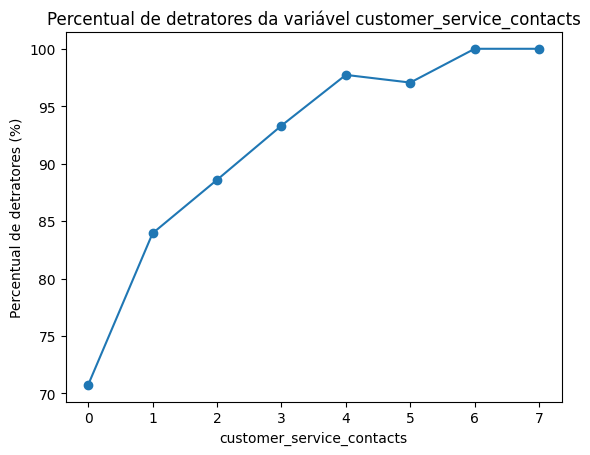

In [ ]:
plot_linhas(df, 'customer_service_contacts')

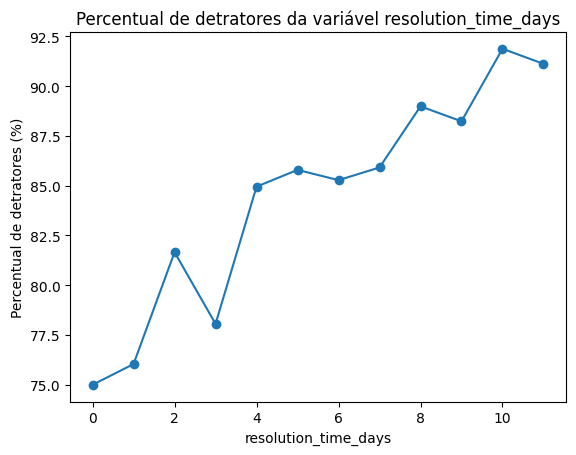

In [ ]:
plot_linhas(df, 'resolution_time_days')

Na finalização desta análise, conseguimos avaliar que, como a base já é 84% detratora, todas as curvas partem de um nível alto dentro do gráfico, e não de 0%. Foi possível verificar em que momento acontece a ruptura entre nossos serviços e o NPS do cliente:

- **Delivery Delay Days** → Com 0 dias de atraso, 51,6% dos clientes já são detratores, com 1 dia de atraso, esse percentual salta para 74%, um salto de 22 pontos. Isso mostra que a reação do cliente é imediata, não existe uma "zona de tolerância" a atraso.

- **Complaints** → Aqui está o maior salto de toda a análise: entre 1 e 2 reclamações, o percentual de detratores salta de 30,3% para 65,3%, um salto de 35 pontos. 

- **Customer Service Contacts** → Aqui a base já parte de um nível alto: clientes com 0 contatos já têm 70,8% de detratores. O maior salto (+13 pontos) acontece entre 0 e 1 contato, estabilizando perto de 100% a partir de 2 contatos.

- **Resolution Time Days** → Sem ponto de ruptura, mantém uma curva achatada e ruidosa ao longo de todo o intervalo, o que reflete o problema de qualidade de dado já identificado no capítulo de Data Quality.

As variáveis que mais trazem ruptura para o negócio são `delivery_delay_days` e `complaints_count`. Porém, entre essas duas, `complaints_count` é a mais acionável na prática: o atraso só é percebido depois que o pedido já saiu errado, quando pouco pode ser feito por aquele pedido específico. Já a reclamação é um evento que acontece durante a jornada e pode ser monitorado em tempo real assim que o sistema detecta a segunda reclamação de um cliente, a empresa ainda está a tempo de agir (por exemplo, com uma ação proativa de atendimento, como um cupom de desconto ou frete grátis, antes que o cliente chegue à pesquisa de NPS como detrator).

## Conclusão EDA

Este notebook partiu de uma pergunta central: quais fatores operacionais realmente influenciam a satisfação do cliente, e como a empresa pode agir antes mesmo da pesquisa de NPS ser aplicada? Depois de percorrer qualidade de dados, exploração variável por variável, ranking de correlação, comparação de perfil por grupo e pontos de ruptura, a resposta convergiu de forma consistente pelas três abordagens diferentes que usamos.

O panorama geral da nossa base de daddos: a base tem NPS geral de -79,96, com 84,36% dos clientes classificados como detratores. Não é um problema de nicho e sim a experiência dos nossos clientes.

Quatro fatores explicam a variação da satisfação, todos ligados à execução pós-venda:

- **delivery_delay_days** — o fator mais forte (correlação de -0,60); a reação do cliente é imediata, sem "zona de tolerância", já no primeiro dia de atraso, o percentual de detratores salta de 51,6% para 74%.

- **complaints_count** — segundo fator mais forte (correlação de -0,50); contém o ponto de ruptura mais nítido de toda a análise, entre a 1ª e a 2ª reclamação (salto de 35 pontos percentuais).

- **customer_service_contacts** — terceiro fator (correlação de -0,35); cada contato adicional reduz o NPS médio em quase 1 ponto.

- **resolution_time_days** — o mais fraco dos quatro (correlação de -0,19), provavelmente porque está diluído por uma inconsistência de qualidade de dado (tempos de resolução registrados mesmo para clientes sem contato).

**O que não explica a satisfação, apesar de testado com o mesmo rigor**: preço, desconto, parcelamento, quantidade de itens, idade, região e tempo de casa do cliente, nenhuma dessas variáveis mostrou relação relevante com o NPS. Isso é, em si, um achado de negócio: a insatisfação não nasce de política comercial nem do perfil demográfico do cliente, nasce de como é está sendo a experiência pós compra do nosso cliente.

**Limitações na base de dados**: identificamos inconsistências reais na base:

- 1,4% dos pedidos com desconto maior que o valor do pedido
- 4,84% com atraso maior que o próprio tempo total de entrega
- 21,24% com reclamação registrada sem nenhum contato de atendimento. 

Além disso, a base é fortemente desbalanceada entre categorias de NPS (84% detrator vs. 4% promotor), o que precisará ser considerado na etapa de modelagem preditiva.

**Recomendação da EDA**: os dados apontam dois gatilhos operacionais concretos, que a empresa pode monitorar em tempo real, antes mesmo da pesquisa de NPS ser aplicada:

- **Gatilho de reclamação**: no momento em que um cliente registra a 2ª reclamação, a chance de ele se tornar detrator salta de 30% para 65%, esse é o ponto exato em que a empresa ainda tem chance de reverter a situação. Uma regra automática de escalonamento nesse momento (atendimento prioritário, cupom de desconto, frete grátis na próxima compra) age antes que o problema se torne irreversível, em vez de esperar uma 3ª ou 4ª reclamação.

- **Gatilho de atraso**: como a reação do cliente ao atraso é imediata já no 1º dia, o percentual de detratores salta de 51,6% para 74%, não é possível esperar o pedido chegar atrasado pra agir. A ação precisa ser um alerta automático assim que o sistema logístico prevê que a entrega vai atrasar, disparando uma comunicação proativa (aviso antecipado, pedido de desculpas, compensação) antes que o cliente perceba o atraso sozinho.

Em ambos os casos, a lógica é a mesma: transformar sinais operacionais que já existem dentro da empresa como: reclamações e previsão de atraso, em um alarme antecipado de insatisfação, permitindo agir enquanto ainda há tempo de reverter a experiência do cliente, em vez de descobrir o problema só quando a pesquisa de NPS chega, como acontece hoje.